In [4]:
import numpy as np
import matplotlib.pyplot as plt
# Project Path Setup
from setup_project_path import (
    check_and_add_project_path,
)  # Script to check and add project path
check_and_add_project_path()
from src.utils.common_funcs import  set_time_grid, cont_integral
from src.spec_dens.spec_dens import spec_dens_gapless

In [7]:
Lambda = 50 #cutoff frequency
N_max = 100 #number of time steps
beta = 0 #inverse temperature
sharpness = 10 #sharpness is nu which is MULTIPLIED with (w-Lambda) in the exponent
delta_t = 0.1

# Define the spectral density
spec_dens = lambda x: spec_dens_gapless(x, cutoff_lower=-Lambda, cutoff_upper=Lambda, sharpness=sharpness) 


/Users/julianthoenniss/Documents/PhD/code/channel_IF/RealTimeID/ModesEnv/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/julianthoenniss/Documents/PhD/code/channel_IF/RealTimeID/ModesEnv/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


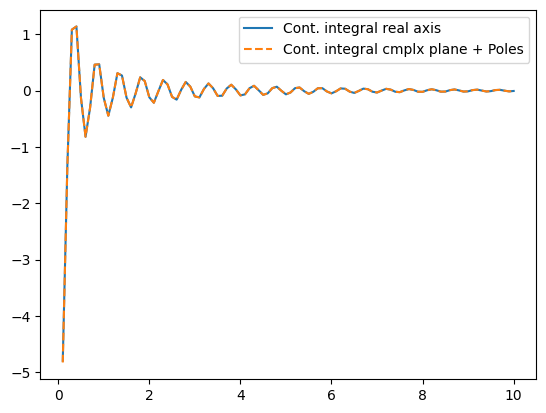

In [8]:
#create the time grid
time_grid = set_time_grid(N_max, delta_t)

#compute the continuous integral along REAL AXIS for only POSITIVE frequencies
cont_integral_particle = cont_integral(time_grid, beta, upper_cutoff=np.inf, spec_dens=spec_dens ,phi = 0., only_positive=True) #particle
cont_integral_hole = cont_integral(time_grid, -beta, upper_cutoff=np.inf, spec_dens = spec_dens,phi = 0., only_positive=True) #hole

#compute the continuous integral along COMPLEX AXIS for only POSITIVE frequencies
cont_integral_particle_cmplx = cont_integral(time_grid, beta, upper_cutoff=np.inf, spec_dens = spec_dens, only_positive=True)#particle
cont_integral_particle_cmplx = cont_integral(time_grid, -beta, upper_cutoff=np.inf, spec_dens = spec_dens, only_positive=True)#hole


def pole_freqs(Lambda, nu, k):
    return Lambda + 2.j * np.pi * nu * (k+0.5)

kappa = Lambda / (2.j * np.pi * sharpness)
poles_freq_table = np.array([pole_freqs(Lambda, .1, k) for k in range (1 + np.floor(np.tan(np.pi/4) * 159.155 - 0.5).astype(int))])


kernel_particles = - .1 * 2.j * np.pi * np.exp(1.j * time_grid[:,np.newaxis] * poles_freq_table) * 1/( 1 + np.exp(beta * poles_freq_table) )


G_poles = np.sum(kernel_particles, axis = 1)


plt.plot(time_grid, cont_integral_particle , label= "Cont. integral real axis")
plt.plot(time_grid, G_poles + cont_integral_particle_cmplx , label = "Cont. integral cmplx plane + Poles", linestyle = "--")

plt.legend()



